# Dr. Case Notebook
# P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Denise Case](https://github.com/denisecase/)
- Repository: [nlp-03-text-exploration](https://github.com/denisecase/nlp-03-text-exploration/)
- Date: 2026-03

Purpose

  Perform exploratory analysis of a small, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

This is a Markdown cell.

## Section 0. Intro to Jupyter Notebooks

This is a Markdown cell.

Tips:
- Run a cell with Ctrl+Enter (Cmd+Enter on Mac)
- Select a kernel (your .venv)
- Use Run All before committing

TODO: Delete or customize this section.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

This is a Markdown cell.

In [25]:
# Section 1 Python cell

from collections import defaultdict
import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

This is a Markdown cell.

In [26]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-26 19:18:35 | INFO | CI | === RUN START ===
2026-03-26 19:18:35 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-26 19:18:35 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-26 19:18:35 | INFO | CI | python=3.14.0
2026-03-26 19:18:35 | INFO | CI | os=Windows 11
2026-03-26 19:18:35 | INFO | CI | shell=powershell
2026-03-26 19:18:35 | INFO | CI | cwd=notebooks
2026-03-26 19:18:35 | INFO | CI | github_actions=False
2026-03-26 19:18:35 | INFO | CI | ROOT_PATH = .
2026-03-26 19:18:35 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-26 19:18:35 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-26 19:18:35 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

This is a Markdown cell.

In [27]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus = [
    # Transport
    {"category": "transport", "text": "Public transport is slow and unreliable"},
    {"category": "transport", "text": "Public transport is always late"},
    {"category": "transport", "text": "Buses are crowded and buses are late"},
    {"category": "transport", "text": "Transport service is very slow"},
    {"category": "transport", "text": "Buses are unreliable and crowded"},
    {"category": "transport", "text": "Public transport needs improvement"},
    # Cleanliness
    {"category": "cleanliness", "text": "The streets are dirty and full of trash"},
    {"category": "cleanliness", "text": "Garbage collection is very poor"},
    {"category": "cleanliness", "text": "The city is dirty and not clean"},
    {"category": "cleanliness", "text": "Trash is everywhere in the streets"},
    {"category": "cleanliness", "text": "Cleanliness needs improvement"},
    # Safety
    {"category": "safety", "text": "The city feels safe during the day"},
    {"category": "safety", "text": "The city is not safe at night"},
    {"category": "safety", "text": "There is not enough police presence"},
    {"category": "safety", "text": "Safety is improving in some areas"},
    {"category": "safety", "text": "People feel unsafe at night"},
    # Services
    {"category": "services", "text": "Public services are improving"},
    {"category": "services", "text": "Customer service is very poor"},
    {"category": "services", "text": "Government services are slow"},
    {"category": "services", "text": "Services need improvement"},
    {"category": "services", "text": "Public services are unreliable"},
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 21 documents.


## Section 3. Tokenize and Clean Text

This is a Markdown cell.

In [28]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

# Define a function to tokenize text by lowercasing, splitting on whitespace,
# and stripping common punctuation. We also filter out very short tokens (length <= 2).
# This simple tokenizer is sufficient for our small, controlled corpus.
# Use the string strip() method to remove punctuation from the beginning and end of each token.
STOPWORDS = {"the", "a", "in", "on", "and", "is", "of", "to", "has"}


def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    cleaned = [t.strip(".,:;!?()[]\"'") for t in tokens]
    return [t for t in cleaned if len(t) > 2 and t not in STOPWORDS]


# Define a new empty list to hold the token records we will create.
records_list: list[dict[str, str]] = []
# Loop through each document, tokenize the text,
# and create a record for each token with its category and
# add it to our list of records.
for doc in corpus:
    # Call our function to tokenize the text of the current document.
    tokens = tokenize(doc["text"])
    # Loop through each token produced by the tokenizer and
    # create a record that includes the category of the document and the token itself.
    # Append this record to our list of records.
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create a Polars DataFrame from the list of token records for easier analysis.
token_df: pl.DataFrame = pl.DataFrame(records_list)

# Show results
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌───────────┬────────────┐
│ category  ┆ token      │
│ ---       ┆ ---        │
│ str       ┆ str        │
╞═══════════╪════════════╡
│ transport ┆ public     │
│ transport ┆ transport  │
│ transport ┆ slow       │
│ transport ┆ unreliable │
│ transport ┆ public     │
│ transport ┆ transport  │
│ transport ┆ always     │
│ transport ┆ late       │
│ transport ┆ buses      │
│ transport ┆ are        │
└───────────┴────────────┘


## Section 4. Compute Global Token Frequencies

This is a Markdown cell.

In [29]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

# Create a DataFrame that groups the tokens by their text and
# counts how many times each token appears across the entire corpus.
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)

# Show results
print("Top global tokens:")
print(global_freq_df.head(10))

Top global tokens:
shape: (10, 2)
┌────────────┬─────┐
│ token      ┆ len │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ are        ┆ 7   │
│ public     ┆ 5   │
│ services   ┆ 4   │
│ transport  ┆ 4   │
│ city       ┆ 3   │
│ slow       ┆ 3   │
│ buses      ┆ 3   │
│ not        ┆ 3   │
│ unreliable ┆ 3   │
│ very       ┆ 3   │
└────────────┴─────┘


## Section 5. Compute Token Frequencies by Category

This is a Markdown cell.

In [30]:
# Section 5 Python cell

# Compare token usage across categories.

# Create a new DataFrame that groups the tokens by both their category and text,
# counts how many times each token appears within each category,
# and sorts the results first by category and then by frequency in descending order.
# This shows which tokens are most common within each category.
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

# Show results
print("Top tokens by category:")
print(category_freq_df.head(12))

Top tokens by category:
shape: (12, 3)
┌───────────┬─────────────┬─────┐
│ category  ┆ token       ┆ len │
│ ---       ┆ ---         ┆ --- │
│ str       ┆ str         ┆ u32 │
╞═══════════╪═════════════╪═════╡
│ transport ┆ transport   ┆ 4   │
│ transport ┆ are         ┆ 3   │
│ transport ┆ buses       ┆ 3   │
│ transport ┆ public      ┆ 3   │
│ transport ┆ unreliable  ┆ 2   │
│ …         ┆ …           ┆ …   │
│ transport ┆ late        ┆ 2   │
│ transport ┆ improvement ┆ 1   │
│ transport ┆ always      ┆ 1   │
│ transport ┆ very        ┆ 1   │
│ transport ┆ needs       ┆ 1   │
└───────────┴─────────────┴─────┘


## Section 6. Identify Top Tokens per Category

This is a Markdown cell.

In [31]:
# Section 6 Python cell

# Show top tokens per category.


# Define a new empty dictionary to store the top tokens for each category.
top_per_category_dict: dict[str, list[str]] = {}

# Loop through each unique category in the token DataFrame,
# filter the category frequency DataFrame to get the top 5 tokens for that category,
# and store the list of top tokens in the dictionary.
# Also, print the top tokens for each category.
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    # Show results for this category
    print(f"{category.upper()} top tokens: {top_tokens_list}")

SAFETY top tokens: ['safe', 'city', 'not', 'night', 'presence']
SERVICES top tokens: ['services', 'are', 'public', 'need', 'improving']
TRANSPORT top tokens: ['transport', 'are', 'buses', 'public', 'unreliable']
CLEANLINESS top tokens: ['trash', 'streets', 'dirty', 'garbage', 'very']


## Section 7. Analyze Co-occurrence (Context Windows)

This is a Markdown cell.

In [32]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

# Define how many tokens on each side of a target token we include as context.
# A window size of 2 means:
#   - up to 2 tokens before the target token
#   - up to 2 tokens after the target token
# The target token itself is not included in its context list.
WINDOW_SIZE: int = 2

# Define a new empty dictionary to store the co-occurrence information.
# The keys will be target tokens,
# and the values will be lists of context tokens that appear near the target token.
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

# Loop through each document in the corpus, tokenize the text,
# and for each token, determine its context tokens based on the defined window size.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

# Show results
for target in ["transport", "cleanliness", "safety", "services"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'transport':
['public', 'slow', 'unreliable', 'public', 'always', 'late', 'service', 'very', 'public', 'needs']

Context for 'cleanliness':
['needs', 'improvement']

Context for 'safety':
['improving', 'some']

Context for 'services':
['public', 'are', 'improving', 'government', 'are', 'slow', 'need', 'improvement', 'public', 'are']


## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

This is a Markdown cell.

In [33]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

# Bigrams capture pairs of consecutive tokens.

# Define a new empty list to hold the bigram tuples we will create.
bigrams_list: list[tuple[str, str]] = []

# Loop through each document in the corpus, tokenize the text,
# and create bigrams by pairing each token with the next token in the list.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

# Create a DataFrame from the list of bigram tuples,
# where each bigram is represented as a single string with the two tokens separated by a space.
bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)

# Create a new DataFrame that groups the bigrams by their text
# and counts how many times each bigram appears,
# then sorts the results by frequency in descending order.
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

# Show results
print("\nTop bigrams per category:")

category_bigrams = []

for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        category_bigrams.append(
            {"category": doc["category"], "bigram": f"{tokens[i]} {tokens[i + 1]}"}
        )

category_bigram_df = pl.DataFrame(category_bigrams)

category_bigram_freq = (
    category_bigram_df.group_by(["category", "bigram"])
    .len()
    .sort(["category", "len"], descending=True)
)

for category in category_bigram_df["category"].unique().to_list():
    top_bigrams = category_bigram_freq.filter(pl.col("category") == category).head(3)
    print(f"{category.upper()} top bigrams:")
    print(top_bigrams.select(["bigram", "len"]))


Top bigrams per category:
TRANSPORT top bigrams:
shape: (3, 2)
┌──────────────────┬─────┐
│ bigram           ┆ len │
│ ---              ┆ --- │
│ str              ┆ u32 │
╞══════════════════╪═════╡
│ public transport ┆ 3   │
│ buses are        ┆ 3   │
│ crowded buses    ┆ 1   │
└──────────────────┴─────┘
CLEANLINESS top bigrams:
shape: (3, 2)
┌───────────────────┬─────┐
│ bigram            ┆ len │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ dirty full        ┆ 1   │
│ very poor         ┆ 1   │
│ cleanliness needs ┆ 1   │
└───────────────────┴─────┘
SAFETY top bigrams:
shape: (3, 2)
┌─────────────────┬─────┐
│ bigram          ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ improving some  ┆ 1   │
│ police presence ┆ 1   │
│ feel unsafe     ┆ 1   │
└─────────────────┴─────┘
SERVICES top bigrams:
shape: (3, 2)
┌─────────────────┬─────┐
│ bigram          ┆ len │
│ ---             ┆ --- │
│ str             ┆ 

## Section 9. Visualize Token Frequencies

This is a Markdown cell.



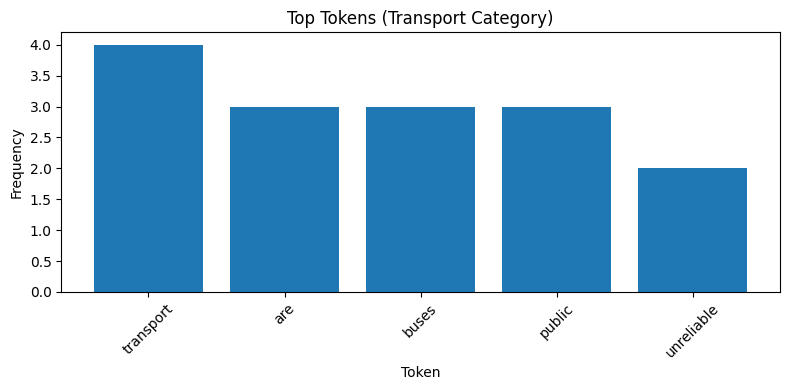

In [34]:
# Section 9 Python cell

city_df = category_freq_df.filter(pl.col("category") == "transport").head(5)

plt.figure(figsize=(8, 4))

plt.bar(city_df["token"].to_list(), city_df["len"].to_list())

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Top Tokens (Transport Category)")
plt.xlabel("Token")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Section 10. Interpret Results and Identify Patterns

This is a Markdown cell.

In [38]:
# Section 10 Python cell


print("\nCASE GENERAL OBSERVATIONS:")

print("- Tokens cluster by category (transport, cleanliness, safety, services).")
print(
    "- Words that appear in similar contexts behave similarly across city-related issues."
)
print(
    "- Co-occurrence reveals relationships between key concerns such as delays, safety, and cleanliness."
)
print("- Bigrams capture local structure such as 'public transport' and 'very poor'.")
print(
    "- Patterns emerge from citizen feedback before applying any machine learning models."
)

print("\nYOURNAME SPECIFIC OBSERVATIONS:")
print("- Transport issues are mainly related to delays, crowding, and unreliability.")
print(
    "- Cleanliness problems are strongly linked to trash and poor garbage collection."
)
print(
    "- Safety concerns focus on lack of police presence and unsafe conditions at night."
)
print("- Public services are often described as slow and needing improvement.")
print(
    "- Frequent word pairs (bigrams) reveal key patterns such as 'public transport' and 'very poor'."
)


CASE GENERAL OBSERVATIONS:
- Tokens cluster by category (transport, cleanliness, safety, services).
- Words that appear in similar contexts behave similarly across city-related issues.
- Co-occurrence reveals relationships between key concerns such as delays, safety, and cleanliness.
- Bigrams capture local structure such as 'public transport' and 'very poor'.
- Patterns emerge from citizen feedback before applying any machine learning models.

YOURNAME SPECIFIC OBSERVATIONS:
- Transport issues are mainly related to delays, crowding, and unreliability.
- Cleanliness problems are strongly linked to trash and poor garbage collection.
- Safety concerns focus on lack of police presence and unsafe conditions at night.
- Public services are often described as slow and needing improvement.
- Frequent word pairs (bigrams) reveal key patterns such as 'public transport' and 'very poor'.


In [36]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-26 19:18:35 | INFO | CI | ========================
2026-03-26 19:18:35 | INFO | CI | Notebook executed successfully!
2026-03-26 19:18:35 | INFO | CI | ========================


Notebook executed successfully.
